In [ ]:
!pip install kaggle -q

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vlasych","key":"892eac8e42df76b4678e8ed51c513746"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mkechinov/ecommerce-behavior-data-from-multi-category-store

Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store
License(s): copyright-authors
100% 4.29G/4.29G [00:40<00:00, 114MB/s]



In [ ]:
!unzip ecommerce-behavior-data-from-multi-category-store.zip

Archive:  ecommerce-behavior-data-from-multi-category-store.zip
  inflating: 2019-Nov.csv            
  inflating: 2019-Oct.csv            


In [ ]:
!ls

2019-Nov.csv					       kaggle.json
2019-Oct.csv					       sample_data
ecommerce-behavior-data-from-multi-category-store.zip


In [ ]:
import pandas as pd

oct_df = pd.read_csv('2019-Oct.csv', nrows=300_000)
nov_df = pd.read_csv('2019-Nov.csv', nrows=300_000)

df = pd.concat([oct_df, nov_df], ignore_index=True)

In [ ]:
df.head()
df.info()
df['event_type'].value_counts()
df['user_id'].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     600000 non-null  object 
 1   event_type     600000 non-null  object 
 2   product_id     600000 non-null  int64  
 3   category_id    600000 non-null  int64  
 4   category_code  405931 non-null  object 
 5   brand          512738 non-null  object 
 6   price          600000 non-null  float64
 7   user_id        600000 non-null  int64  
 8   user_session   600000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 41.2+ MB


111878

In [ ]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [ ]:
df = df.drop_duplicates()
df = df[df['price'] > 0]

In [ ]:
df.groupby('event_type')['user_id'].nunique()

,user_id
event_type,
cart,5124
purchase,8686
view,111795


In [ ]:
view_users = set(df[df['event_type'] == 'view']['user_id'])
cart_users = set(df[df['event_type'] == 'cart']['user_id'])
purchase_users = set(df[df['event_type'] == 'purchase']['user_id'])

purchase_without_cart = purchase_users - cart_users

len(purchase_without_cart) / len(purchase_users)

0.6482845959014506

In [ ]:
converted_users = purchase_users & view_users

len(converted_users) / len(view_users)

0.07757949818864887

# **H1: Значительная часть пользователей совершает покупку без этапа добавления в корзину**

*   Количество пользователей, совершивших покупку (8 686), превышает количество пользователей, добавивших товар в корзину (5 124)  
*   Около 64.8% пользователей, совершивших покупку, не использовали корзину  
*   Классическая воронка view → cart → purchase не полностью отражает поведение пользователей  
*   Существуют альтернативные сценарии покупки (например, "быстрая покупка"), которые необходимо учитывать при анализе воронки  

In [ ]:
view_users = df[df['event_type'] == 'view']['user_id'].nunique()
purchase_users = df[df['event_type'] == 'purchase']['user_id'].nunique()

print('view → purchase:', purchase_users / view_users)

view → purchase: 0.07769578245896507


In [ ]:
cart_users = df[df['event_type'] == 'cart']['user_id'].nunique()

print('view → cart:', cart_users / view_users)

view → cart: 0.045833892392325236


# **H2: Конверсия из просмотра в покупку находится на уровне ~7–8%**

*   Конверсия пользователей из просмотра в покупку составляет ~7.7%  
*   Конверсия из просмотра в добавление в корзину — ~4.6%  
*   Конверсия в покупку выше, чем в корзину, что подтверждает существование альтернативных сценариев покупки  
*   Основные потери происходят между первым просмотром и принятием решения о покупке  

In [ ]:
df.groupby('user_id')['event_type'].count().describe()

,event_type
count,111811.000000
mean,5.357764
std,7.810994
min,1.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,413.000000


# **H3: Поведение пользователей характеризуется высокой неоднородностью**

*   Медианное количество событий на пользователя составляет 3 (по данным .describe())  
*   Среднее значение — 5.4, что значительно выше медианы, что указывает на правостороннее распределение  
*   Наблюдается небольшая группа высокоактивных пользователей (максимум — 413 событий)  
*   Это подтверждает необходимость сегментации пользователей по активности  

In [ ]:
user_events = df.groupby('user_id')['event_type'].count()

df_users = user_events.reset_index()
df_users.columns = ['user_id', 'events']

df_users['segment'] = pd.qcut(
    df_users['events'],
    q=3,
    labels=['low', 'medium', 'high']
)

In [ ]:
df_segment = df.merge(df_users, on='user_id')

df_segment[df_segment['event_type'] == 'purchase'] \
    .groupby('segment')['user_id'].nunique()

/tmp/ipykernel_7059/3611232661.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('segment')['user_id'].nunique()


,user_id
segment,
low,578
medium,3354
high,4754


In [ ]:
users_per_segment = df_users.groupby('segment')['user_id'].nunique()

/tmp/ipykernel_7059/203246899.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_per_segment = df_users.groupby('segment')['user_id'].nunique()


In [ ]:
buyers_per_segment = df_segment[df_segment['event_type'] == 'purchase'] \
    .groupby('segment')['user_id'].nunique()

/tmp/ipykernel_7059/2087127529.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('segment')['user_id'].nunique()


In [ ]:
conversion = buyers_per_segment / users_per_segment
conversion

,user_id
segment,
low,0.011183
medium,0.117260
high,0.150815


# **H4: Вероятность покупки напрямую зависит от уровня активности пользователя**

*   Конверсия в покупку существенно различается между сегментами пользователей  
*   Пользователи с низкой активностью демонстрируют крайне низкую вероятность покупки (~1.1%)  
*   Пользователи со средней активностью имеют значительно более высокий уровень конверсии (~11.7%)  
*   Наиболее активные пользователи показывают максимальную конверсию (~15.1%)  
*   Разница в конверсии между сегментами достигает более чем 10-кратного значения  
*   Это подтверждает сильную зависимость между вовлеченностью пользователя и вероятностью совершения покупки  

In [ ]:
revenue = df_segment[df_segment['event_type'] == 'purchase'] \
    .groupby('segment')['price'].sum()

revenue

/tmp/ipykernel_7059/757273560.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('segment')['price'].sum()


,price
segment,
low,142587.44
medium,1145480.70
high,2095991.61


In [ ]:
avg_revenue = revenue / buyers_per_segment
avg_revenue

,0
segment,
low,246.691073
medium,341.526744
high,440.890116


# **H5: Основная выручка формируется за счет пользователей с высокой активностью**

*   Пользователи с высокой активностью генерируют наибольший объем выручки (~2 096 тыс.)  
*   Сегмент со средней активностью вносит значительный вклад (~1 145 тыс.)  
*   Пользователи с низкой активностью практически не участвуют в формировании выручки (~143 тыс.)  
*   Средняя выручка на покупателя также растёт с активностью: low ~247, medium ~342, high ~441  
*   Это указывает на ключевую роль вовлеченности в монетизации продукта  

In [ ]:
first_activity = df.groupby('user_id')['date'].min().reset_index()
first_activity.columns = ['user_id', 'cohort_date']

df = df.merge(first_activity, on='user_id')

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['cohort_date'] = pd.to_datetime(df['cohort_date'])

In [ ]:
df['cohort_month'] = pd.to_datetime(df['cohort_date']).dt.to_period('M')
df['activity_month'] = pd.to_datetime(df['date']).dt.to_period('M')

df['months_since'] = (df['activity_month'] - df['cohort_month']).apply(lambda x: x.n)

In [ ]:
cohort = df.groupby(['cohort_month', 'months_since'])['user_id'].nunique().unstack()
cohort = cohort.div(cohort[0], axis=0)
cohort.head()

months_since,0,1
cohort_month,,
2019-10,1.0,0.03443
2019-11,1.0,NaN


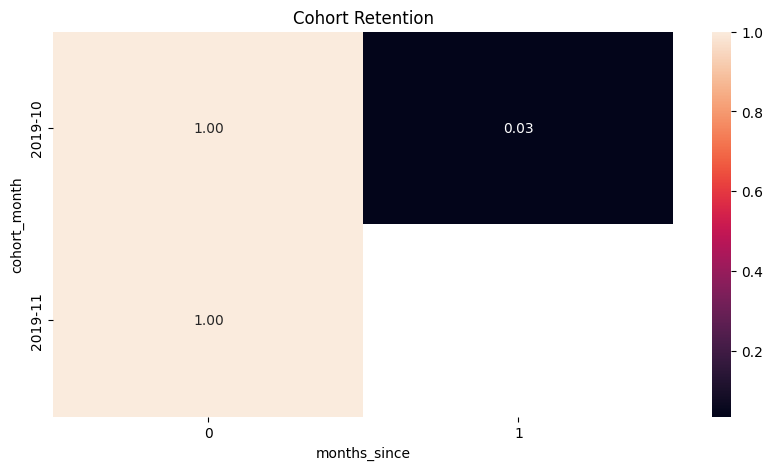

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(cohort, annot=True, fmt=".2f")
plt.title('Cohort Retention')
plt.show()

# **H6: Поведение пользователей в разных когортах демонстрирует схожие паттерны удержания**

*   Все когорты демонстрируют схожую динамику снижения retention  
*   Основной отток происходит в первые периоды после привлечения  
*   Это подтверждает системную проблему удержания пользователей  

In [ ]:
df_users['group'] = df_users['user_id'] % 2
df_segment = df_segment.merge(df_users[['user_id', 'group']], on='user_id')

In [ ]:
conversion_ab = df_segment[df_segment['event_type'] == 'purchase'] \
    .groupby('group')['user_id'].nunique()

users_ab = df_segment.groupby('group')['user_id'].nunique()

conversion_rate = conversion_ab / users_ab
conversion_rate

,user_id
group,
0,0.077250
1,0.078121


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

success = conversion_ab.values
total = users_ab.values

stat, p = proportions_ztest(success, total)
print(p)

0.5863545093855003


# **H7: Демонстрация методологии A/B-тестирования на исторических данных**

*   Пользователи разделены на две группы по остатку от деления user_id на 2 — это псевдослучайное разбиение на исторических данных, не настоящий эксперимент  
*   Конверсия в группе 0: ~7.7%, в группе 1: ~7.8% — различие минимально  
*   p-value = 0.586, что значительно выше порога 0.05 — различия статистически незначимы  
*   Данный блок иллюстрирует подход к проведению A/B-теста; для реального эксперимента необходимо заранее разделить пользователей на контрольную и тестовую группы до внедрения изменений  

# **Product Recommendations**

*   Необходимо фокусироваться на увеличении вовлеченности пользователей, так как активность напрямую влияет на конверсию и выручку  
*   Следует развивать механики, переводящие пользователей из low в medium сегмент  
*   Рекомендуется усиливать пользовательский опыт для высокоактивных пользователей с целью максимизации их LTV  
*   Важно оптимизировать путь покупки, учитывая, что значительная часть пользователей совершает покупку без этапа добавления в корзину  
*   Необходимо анализировать и улучшать альтернативные сценарии покупки (например, быстрый checkout)  

# **Итоговые выводы продуктовой аналитики**

*   Поведение пользователей характеризуется высокой неоднородностью  
*   Основной отток происходит на ранних этапах взаимодействия  
*   Вовлеченность пользователя напрямую влияет на конверсию и выручку  
*   Пользователи с высокой активностью формируют основной доход продукта  
*   Классическая воронка не полностью отражает поведение пользователей  
*   Необходимо учитывать альтернативные сценарии покупки  